Project Title
#  Seasonal Agriculture Performance Analysis

### Major Project
**Domain:** Agriculture & Data Analytics

## Project Goal

To analyze agricultural performance across different seasons and identify patterns in crop yield, environmental conditions, resource usage, and economic performance.

## 1.Problem Statement

Agricultural performance varies across seasons due to changes in environmental conditions, farming practices, resource availability, and market conditions. This project analyzes seasonal agricultural data to identify important patterns, variations, and relationships.

## 2.Objectives

- Analyze and clean the agricultural dataset.
- Compare agricultural performance across seasons.
- Study environmental and resource-related factors.
- Analyze crop yield, production, revenue, cost, and profit.
- Identify relationships and correlations between important variables.
- Draw meaningful insights and provide recommendations.

## 3.Dataset

The dataset contains agricultural records covering different crops, regions, and seasons, along with information about environmental conditions, soil properties, farming resources, production, yield, water usage, and economic performance.

**Seasons:** Kharif, Rabi, and Zaid.

## 4.Tools & Technologies

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy

In [1]:
#  Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy.stats import f_oneway, kruskal, pearsonr, spearmanr

from google.colab import files
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

os.makedirs("outputs", exist_ok=True)

print("All required libraries imported successfully.")

All required libraries imported successfully.


## 5. Dataset Loading

The agricultural dataset is loaded into a Pandas DataFrame for further exploration, cleaning, statistical analysis, and visualization.

In [2]:
# Load Dataset


uploaded = files.upload()

file_name = next(iter(uploaded))

data = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print(f"File name: {file_name}")
print(f"Number of records: {data.shape[0]:,}")
print(f"Number of variables: {data.shape[1]}")

Saving seasonal_agriculture_performance_dataset (1).csv to seasonal_agriculture_performance_dataset (1).csv
Dataset loaded successfully.
File name: seasonal_agriculture_performance_dataset (1).csv
Number of records: 4,000
Number of variables: 28


## 6. Initial Dataset Exploration

The first stage of analysis is to understand the structure, dimensions, variables, data types, and sample records of the dataset.

In [3]:
# Dataset Structure

print("Dataset Shape")
print("-" * 40)
print(f"Rows    : {data.shape[0]:,}")
print(f"Columns : {data.shape[1]}")

print("\nColumn Names")
print("-" * 40)

for column in data.columns:
    print(column)

print("\nData Types")
print("-" * 40)

display(data.dtypes.to_frame("Data_Type"))

Dataset Shape
----------------------------------------
Rows    : 4,000
Columns : 28

Column Names
----------------------------------------
Farm_ID
State
District
Crop
Season
Farm_Area_Hectares
Rainfall_mm
Avg_Temperature_C
Humidity_pct
Sunlight_Hours_Day
Soil_pH
Soil_Moisture_pct
Nitrogen_kg_ha
Phosphorus_kg_ha
Potassium_kg_ha
Irrigation_Method
Fertilizer_kg_ha
Pesticide_Litre_ha
Seed_Quality_Score
Yield_Tonnes_Ha
Production_Tonnes
Market_Price_INR_Tonne
Total_Cost_INR
Revenue_INR
Profit_INR
Water_Used_m3
Water_Efficiency_t_per_1000m3
Disease_Pest_Risk_pct

Data Types
----------------------------------------


,Data_Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [4]:
# Display Sample Records


display(data.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 7. Dataset Description

The dataset contains information related to:

### Environmental Conditions
- Rainfall
- Temperature
- Humidity
- Sunlight
- Soil pH
- Soil moisture

### Agricultural Characteristics
- Farm area
- Crop
- Seed quality
- Yield
- Production

### Resource Usage
- Nitrogen
- Phosphorus
- Potassium
- Fertilizer
- Pesticide
- Water usage
- Water efficiency

### Economic Variables
- Market price
- Total cost
- Revenue
- Profit

### Risk Indicator
- Disease and pest risk

## 8. Data Quality Assessment

Before performing analysis, the dataset is checked for:

- Missing values
- Duplicate records
- Duplicate Farm IDs
- Incorrect or inconsistent data types

In [5]:
# Missing Value Analysis

missing_summary = pd.DataFrame({
    "Missing_Count": data.isnull().sum(),
    "Missing_Percentage": (
        data.isnull().sum() / len(data) * 100
    ).round(2)
})

missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Count", ascending=False)
)

if missing_summary.empty:
    print("No missing values were found.")
else:
    display(missing_summary)

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [6]:
# Duplicate Analysis

duplicate_rows = data.duplicated().sum()
duplicate_farm_ids = data["Farm_ID"].duplicated().sum()

print(f"Duplicate rows     : {duplicate_rows}")
print(f"Duplicate Farm IDs : {duplicate_farm_ids}")

Duplicate rows     : 0
Duplicate Farm IDs : 0


## 9. Data Cleaning and Preparation

The dataset contains a small number of missing numerical observations.

Median imputation is used for the affected numerical variables because it is less sensitive to extreme observations than mean imputation.

The original dataset is preserved, while a separate cleaned DataFrame is created for analysis.

In [7]:
# Create Clean Dataset

clean_data = data.copy()

missing_numeric_columns = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

for column in missing_numeric_columns:
    clean_data[column] = clean_data[column].fillna(
        clean_data[column].median()
    )

print("Data cleaning completed.")
print(f"Remaining missing values: {clean_data.isnull().sum().sum()}")
print(f"Duplicate rows: {clean_data.duplicated().sum()}")

Data cleaning completed.
Remaining missing values: 0
Duplicate rows: 0


## 10. Descriptive Statistics

Descriptive statistics are calculated to understand the central tendency, dispersion, and range of the numerical variables.

In [8]:
# Descriptive Statistics

descriptive_statistics = clean_data.describe().T

display(descriptive_statistics)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


## 11. Categorical Variable Exploration

The major categorical variables are examined to understand the distribution of:

- States
- Districts
- Crops
- Seasons
- Irrigation methods

In [9]:
# Categorical Variable Summary

categorical_columns = [
    "State",
    "District",
    "Crop",
    "Season",
    "Irrigation_Method"
]

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * 40)
    display(clean_data[column].value_counts().to_frame("Count"))


State
----------------------------------------


,Count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484



District
----------------------------------------


,Count
District,
Ludhiana,427
Warangal,422
Nalgonda,415
Erode,403
Rajkot,401
Krishna,393
Indore,392
Guntur,390
Raichur,386



Crop
----------------------------------------


,Count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305



Season
----------------------------------------


,Count
Season,
Kharif,1779
Rabi,1627
Zaid,594



Irrigation_Method
----------------------------------------


,Count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


# 12. Seasonal Analysis

Seasonal analysis is the central component of this project.

The objective is to compare agricultural performance across Kharif, Rabi, and Zaid seasons using yield, production, economic performance, water usage, water efficiency, and disease/pest risk.

,Number_of_Farms
Season,
Kharif,1779
Rabi,1627
Zaid,594


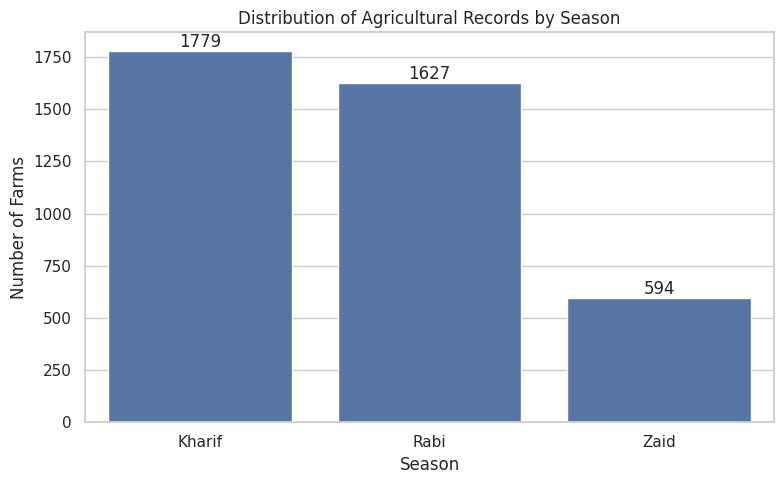

In [14]:
# Season Distribution

# Count records for each season
season_counts = clean_data["Season"].value_counts()

# Display season-wise count
display(
    season_counts.to_frame("Number_of_Farms")
)

# Create bar chart
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=season_counts.index,
    y=season_counts.values
)

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")

# Display values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

# Save figure in Colab outputs folder
plt.savefig(
    "outputs/season_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13. Seasonal Performance Comparison

The following indicators are compared across seasons:

- Average yield
- Average production
- Average revenue
- Average cost
- Average profit
- Average water usage
- Average water efficiency
- Average disease/pest risk

In [15]:
# Seasonal Performance Summary

season_summary = (
    clean_data
    .groupby("Season")
    .agg(
        Farms=("Farm_ID", "count"),
        Average_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
        Average_Production_Tonnes=("Production_Tonnes", "mean"),
        Average_Revenue_INR=("Revenue_INR", "mean"),
        Average_Cost_INR=("Total_Cost_INR", "mean"),
        Average_Profit_INR=("Profit_INR", "mean"),
        Average_Water_Used_m3=("Water_Used_m3", "mean"),
        Average_Water_Efficiency=(
            "Water_Efficiency_t_per_1000m3",
            "mean"
        ),
        Average_Disease_Pest_Risk=(
            "Disease_Pest_Risk_pct",
            "mean"
        )
    )
    .round(2)
)

display(season_summary)

,Farms,Average_Yield_Tonnes_Ha,Average_Production_Tonnes,Average_Revenue_INR,Average_Cost_INR,Average_Profit_INR,Average_Water_Used_m3,Average_Water_Efficiency,Average_Disease_Pest_Risk
Season,,,,,,,,,
Kharif,1779,5.63,46.31,"710,719.06","531,804.41","178,914.65","6,102.20",5.89,54.47
Rabi,1627,5.04,41.49,"601,526.05","513,836.58","87,689.47","5,846.99",5.19,40.48
Zaid,594,4.64,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89",4.41,38.22


## 14. Result 1 — Average Yield by Season

The average yield is compared across Kharif, Rabi, and Zaid seasons to identify seasonal differences in agricultural productivity.

Average Yield by Season
----------------------------------------


,Average_Yield_Tonnes_Ha
Season,
Kharif,5.63
Rabi,5.04
Zaid,4.64


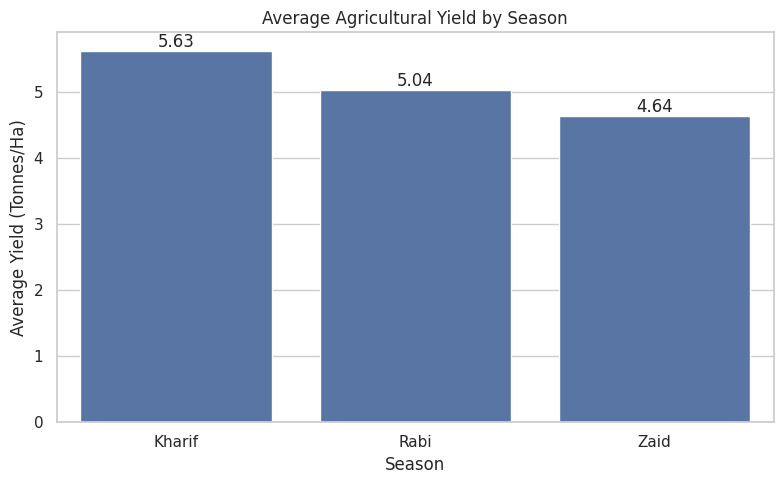

In [16]:
# Result 1: Average Yield by Season


season_yield = (
    clean_data
    .groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Yield by Season")
print("-" * 40)

display(
    season_yield
    .round(2)
    .to_frame("Average_Yield_Tonnes_Ha")
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()

plt.savefig(
    "outputs/seasonal_yield.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Crop-wise Performance Analysis

Crop-wise analysis is performed to identify differences in yield and economic performance among the crops represented in the dataset.

In [17]:
# Crop-wise Performance

crop_summary = (
    clean_data
    .groupby("Crop")
    .agg(
        Farms=("Farm_ID", "count"),
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Production=("Production_Tonnes", "mean"),
        Average_Revenue=("Revenue_INR", "mean"),
        Average_Profit=("Profit_INR", "mean")
    )
    .sort_values("Average_Yield", ascending=False)
    .round(2)
)

display(crop_summary)

,Farms,Average_Yield,Average_Production,Average_Revenue,Average_Profit
Crop,,,,,
Sugarcane,305,46.64,392.41,"1,371,980.11","817,187.99"
Maize,551,2.71,21.78,"457,067.99","-83,978.33"
Rice,690,2.43,19.29,"423,615.26","-102,213.50"
Wheat,614,2.11,16.85,"400,104.89","-123,398.34"
Chilli,412,1.54,12.38,"1,276,777.23","750,878.34"
Groundnut,424,1.32,9.66,"542,935.50","44,858.12"
Cotton,508,1.23,9.40,"639,423.08","124,546.92"
Pulses,496,0.92,7.40,"528,465.87","-4,238.05"


## 16. Result 2 — Average Yield by Crop

The crop-wise comparison highlights which crops have relatively higher or lower average yield within the available dataset.

,Average_Yield_Tonnes_Ha
Crop,
Sugarcane,46.64
Maize,2.71
Rice,2.43
Wheat,2.11
Chilli,1.54
Groundnut,1.32
Cotton,1.23
Pulses,0.92


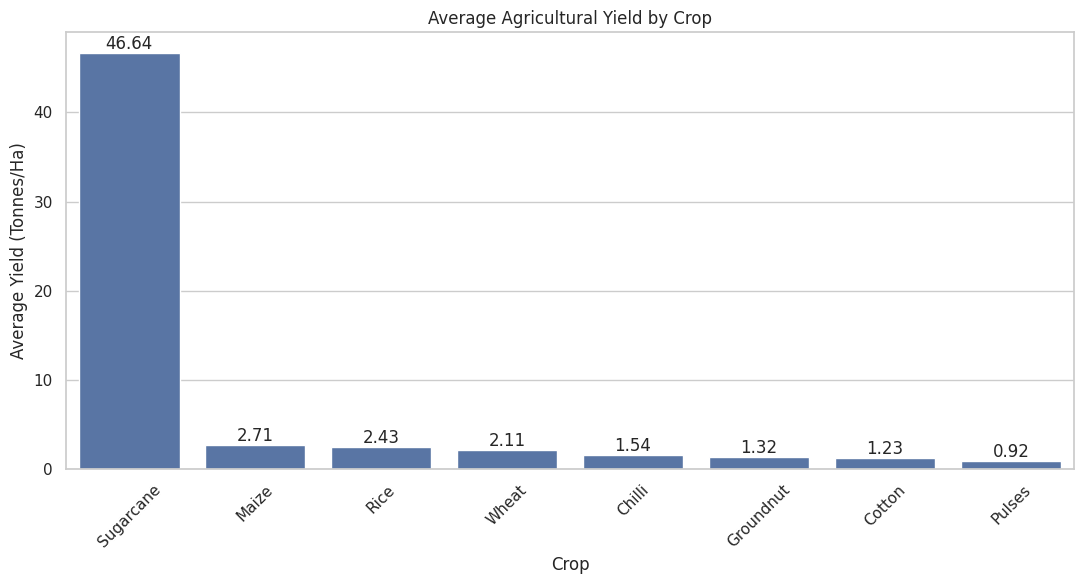

In [18]:
# Result 2: Crop Yield Analysis


crop_yield = (
    clean_data
    .groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

display(
    crop_yield
    .round(2)
    .to_frame("Average_Yield_Tonnes_Ha")
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=crop_yield.index,
    y=crop_yield.values
)

plt.title("Average Agricultural Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()

plt.savefig(
    "outputs/crop_yield.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 17. Season-wise Crop Analysis

Season and crop are analyzed together to determine whether crop-level performance changes across seasons.

In [19]:
# Season x Crop Performance


season_crop_summary = (
    clean_data
    .groupby(["Season", "Crop"])
    .agg(
        Farms=("Farm_ID", "count"),
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean")
    )
    .round(2)
)

display(season_crop_summary)

Farms  Average_Yield  Average_Profit
Season Crop                                           
Kharif Chilli       185           1.73      954,380.42
       Cotton       215           1.37      216,999.55
       Groundnut    193           1.48      108,265.44
       Maize        234           2.97      -39,332.67
       Pulses       221           1.04       43,338.90
       Rice         314           2.70      -64,903.40
       Sugarcane    125          53.46    1,000,790.81
       Wheat        292           2.25     -105,871.87
Rabi   Chilli       163           1.47      638,572.50
       Cotton       201           1.20      107,343.59
       Groundnut    177           1.23       10,416.54
       Maize        233           2.60      -89,133.40
       Pulses       213           0.88      -14,309.14
       Rice         274           2.32      -98,427.87
       Sugarcane    129          43.29      731,612.86
       Wheat        237           2.06     -119,954.57
Zaid   Chilli        64           1.20      448,659.09
       Cotton        92           0.96      -53,925.34
       Groundnut     54           1.04      -68,872.50
       Maize         84           2.29     -194,049.17
       Pulses        62           0.67     -139,227.81
       Rice         102           1.90     -227,239.34
       Sugarcane     51          38.42      583,635.80
       Wheat         85           1.75     -193,208.95

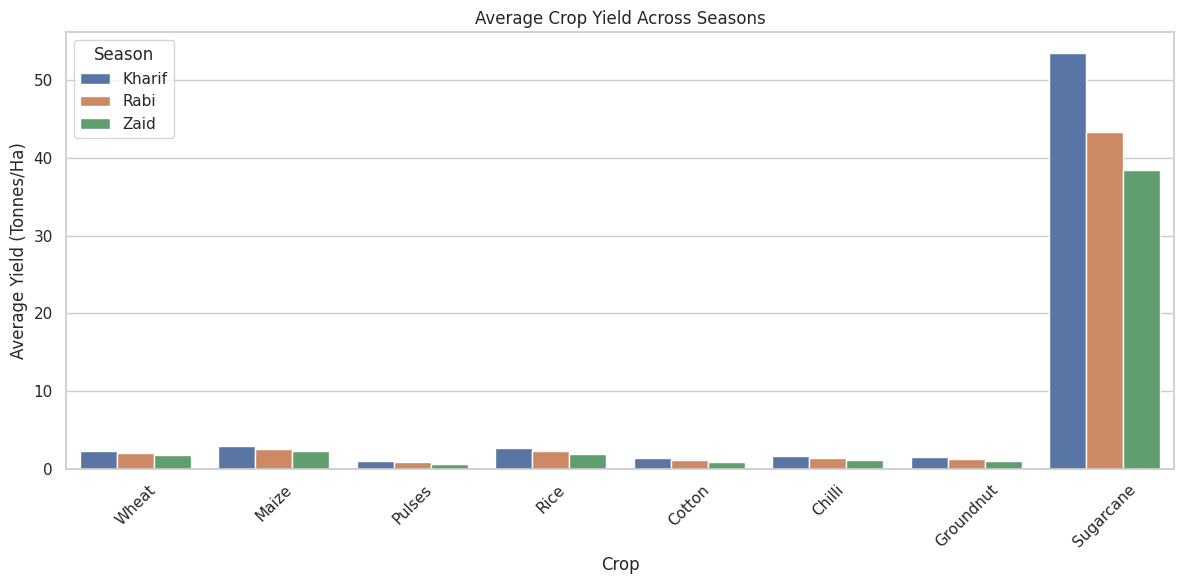

In [20]:
# Season x Crop Yield Visualization

plt.figure(figsize=(12, 6))

sns.barplot(
    data=clean_data,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season",
    estimator="mean",
    errorbar=None
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 18. Irrigation Analysis

Irrigation methods are compared to examine their relationship with yield, profit, water usage, and water efficiency.

In [21]:
# Irrigation Performance

irrigation_summary = (
    clean_data
    .groupby("Irrigation_Method")
    .agg(
        Farms=("Farm_ID", "count"),
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Used=("Water_Used_m3", "mean"),
        Average_Water_Efficiency=(
            "Water_Efficiency_t_per_1000m3",
            "mean"
        )
    )
    .sort_values("Average_Yield", ascending=False)
    .round(2)
)

display(irrigation_summary)

,Farms,Average_Yield,Average_Profit,Average_Water_Used,Average_Water_Efficiency
Irrigation_Method,,,,,
Drip,915,6.58,"219,626.00","5,918.75",6.27
Sprinkler,734,5.16,"91,121.08","6,208.26",4.67
Flood,1310,4.86,"73,354.02","8,026.47",3.44
Rainfed,1041,4.60,"79,050.37","3,549.55",7.56


## 19. Result 3 — Irrigation Method and Yield

The average yield for each irrigation method is compared to identify differences in agricultural performance across irrigation categories.

,Average_Yield_Tonnes_Ha
Irrigation_Method,
Drip,6.58
Sprinkler,5.16
Flood,4.86
Rainfed,4.60


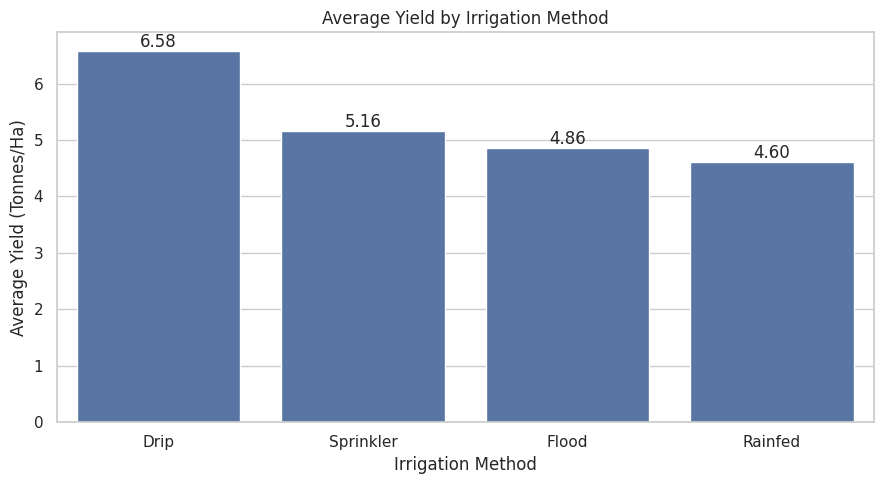

In [22]:
# Result 3: Irrigation Method vs Yield

irrigation_yield = (
    clean_data
    .groupby("Irrigation_Method")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

display(
    irrigation_yield
    .round(2)
    .to_frame("Average_Yield_Tonnes_Ha")
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=irrigation_yield.index,
    y=irrigation_yield.values
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()

plt.savefig(
    "outputs/irrigation_yield.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 20. Environmental Conditions Analysis

Environmental conditions are compared across seasons to understand variations in rainfall, temperature, humidity, sunlight, and soil moisture.

In [23]:
# Environmental Conditions by Season

environment_summary = (
    clean_data
    .groupby("Season")
    .agg(
        Average_Rainfall_mm=("Rainfall_mm", "mean"),
        Average_Temperature_C=("Avg_Temperature_C", "mean"),
        Average_Humidity_pct=("Humidity_pct", "mean"),
        Average_Sunlight_Hours=("Sunlight_Hours_Day", "mean"),
        Average_Soil_Moisture_pct=("Soil_Moisture_pct", "mean")
    )
    .round(2)
)

display(environment_summary)

,Average_Rainfall_mm,Average_Temperature_C,Average_Humidity_pct,Average_Sunlight_Hours,Average_Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


# 21. Resource Usage Analysis

Resource consumption is analyzed across seasons using fertilizer, nutrients, pesticides, and water usage.

This analysis helps identify differences in resource requirements between seasonal agricultural activities.

In [24]:
# Resource Usage by Season

resource_summary = (
    clean_data
    .groupby("Season")
    .agg(
        Average_Nitrogen=("Nitrogen_kg_ha", "mean"),
        Average_Phosphorus=("Phosphorus_kg_ha", "mean"),
        Average_Potassium=("Potassium_kg_ha", "mean"),
        Average_Fertilizer=("Fertilizer_kg_ha", "mean"),
        Average_Pesticide=("Pesticide_Litre_ha", "mean"),
        Average_Water_Used=("Water_Used_m3", "mean")
    )
    .round(2)
)

display(resource_summary)

,Average_Nitrogen,Average_Phosphorus,Average_Potassium,Average_Fertilizer,Average_Pesticide,Average_Water_Used
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,"6,102.20"
Rabi,120.40,57.31,103.93,185.41,5.02,"5,846.99"
Zaid,120.53,58.13,105.42,184.64,5.17,"6,419.89"


# 22. Result 4 — Water Usage and Efficiency

Water usage and water efficiency are compared across seasons.

Water efficiency is evaluated together with water consumption to determine whether higher water usage corresponds to better agricultural performance.

,Average_Water_Used_m3,Average_Water_Efficiency,Average_Yield
Season,,,
Kharif,"6,102.20",5.89,5.63
Rabi,"5,846.99",5.19,5.04
Zaid,"6,419.89",4.41,4.64


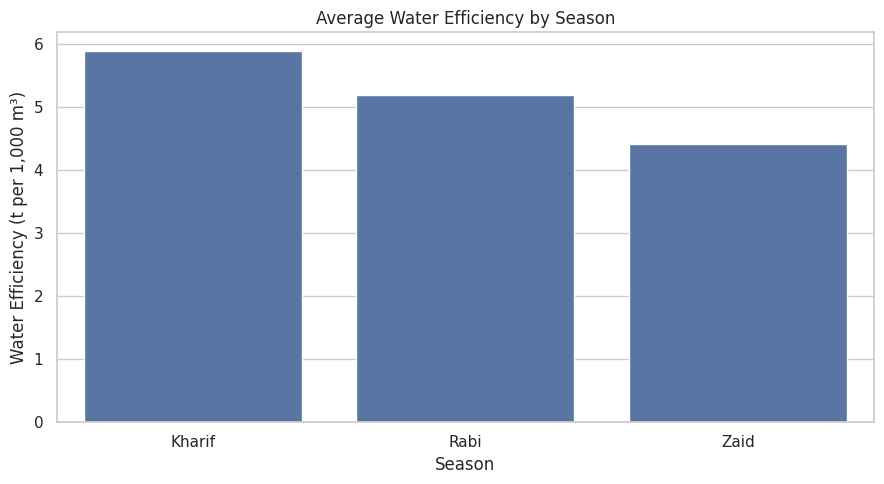

In [25]:
# Result 4: Water Usage and Efficiency

water_summary = (
    clean_data
    .groupby("Season")
    .agg(
        Average_Water_Used_m3=("Water_Used_m3", "mean"),
        Average_Water_Efficiency=(
            "Water_Efficiency_t_per_1000m3",
            "mean"
        ),
        Average_Yield=("Yield_Tonnes_Ha", "mean")
    )
    .round(2)
)

display(water_summary)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=clean_data,
    x="Season",
    y="Water_Efficiency_t_per_1000m3",
    estimator="mean",
    errorbar=None
)

plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (t per 1,000 m³)")

plt.tight_layout()

plt.savefig(
    "outputs/water_efficiency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 23. Economic Performance Analysis

Economic performance is analyzed using:

- Market price
- Total cost
- Revenue
- Profit

This allows agricultural performance to be evaluated from both production and financial perspectives.

In [26]:
# Economic Performance by Season

economic_summary = (
    clean_data
    .groupby("Season")
    .agg(
        Average_Market_Price=("Market_Price_INR_Tonne", "mean"),
        Average_Total_Cost=("Total_Cost_INR", "mean"),
        Average_Revenue=("Revenue_INR", "mean"),
        Average_Profit=("Profit_INR", "mean")
    )
    .round(2)
)

display(economic_summary)

,Average_Market_Price,Average_Total_Cost,Average_Revenue,Average_Profit
Season,,,,
Kharif,"44,850.91","531,804.41","710,719.06","178,914.65"
Rabi,"44,747.97","513,836.58","601,526.05","87,689.47"
Zaid,"44,212.03","543,976.73","519,171.90","-24,804.82"


,Average_Profit_INR
Crop,
Sugarcane,"817,187.99"
Chilli,"750,878.34"
Cotton,"124,546.92"
Groundnut,"44,858.12"
Pulses,"-4,238.05"
Maize,"-83,978.33"
Rice,"-102,213.50"
Wheat,"-123,398.34"


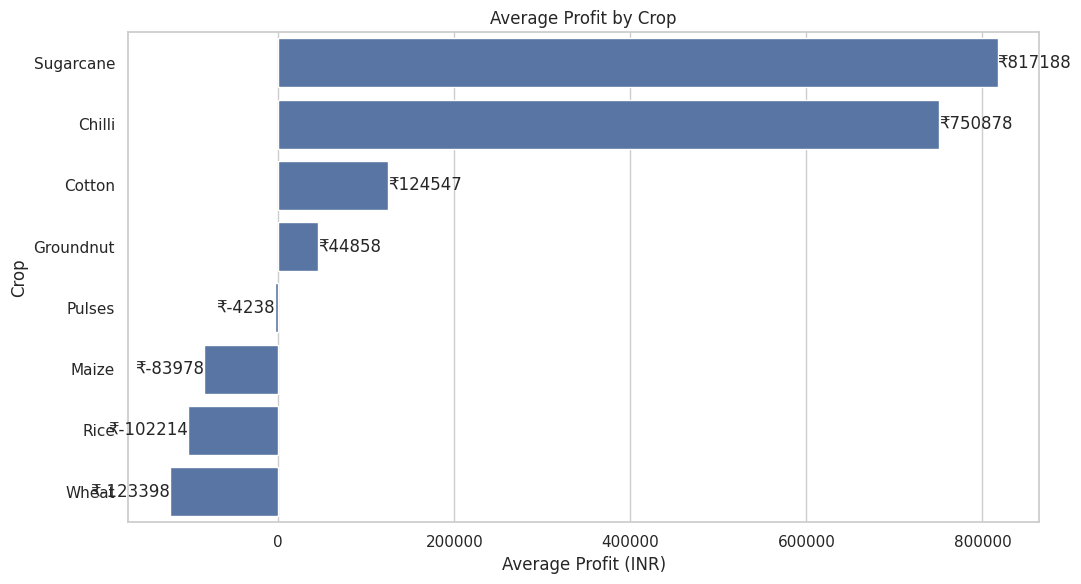

In [27]:
# Crop-wise Profitability

crop_profit = (
    clean_data
    .groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

display(
    crop_profit
    .round(2)
    .to_frame("Average_Profit_INR")
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=crop_profit.values,
    y=crop_profit.index
)

plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")

for container in ax.containers:
    ax.bar_label(container, fmt="₹%.0f")

plt.tight_layout()

plt.savefig(
    "outputs/crop_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 24. Profitability Analysis

A farm is classified as profitable when Profit_INR is greater than zero.

The percentage of profitable farms is calculated for each season to compare seasonal economic performance.

In [28]:
# Profitability Rate by Season

clean_data["Profitable"] = clean_data["Profit_INR"] > 0

profitability_rate = (
    clean_data
    .groupby("Season")["Profitable"]
    .mean()
    .mul(100)
    .round(2)
)

display(
    profitability_rate.to_frame(
        "Profitable_Farms_Percentage"
    )
)

,Profitable_Farms_Percentage
Season,
Kharif,57.79
Rabi,48.86
Zaid,35.52


# 25. Correlation Analysis

Correlation analysis is used to investigate relationships between agricultural, environmental, resource, production, and economic variables.

A correlation coefficient closer to +1 indicates a strong positive relationship, while a value closer to -1 indicates a strong negative relationship.

Correlation represents association and does not establish causation.

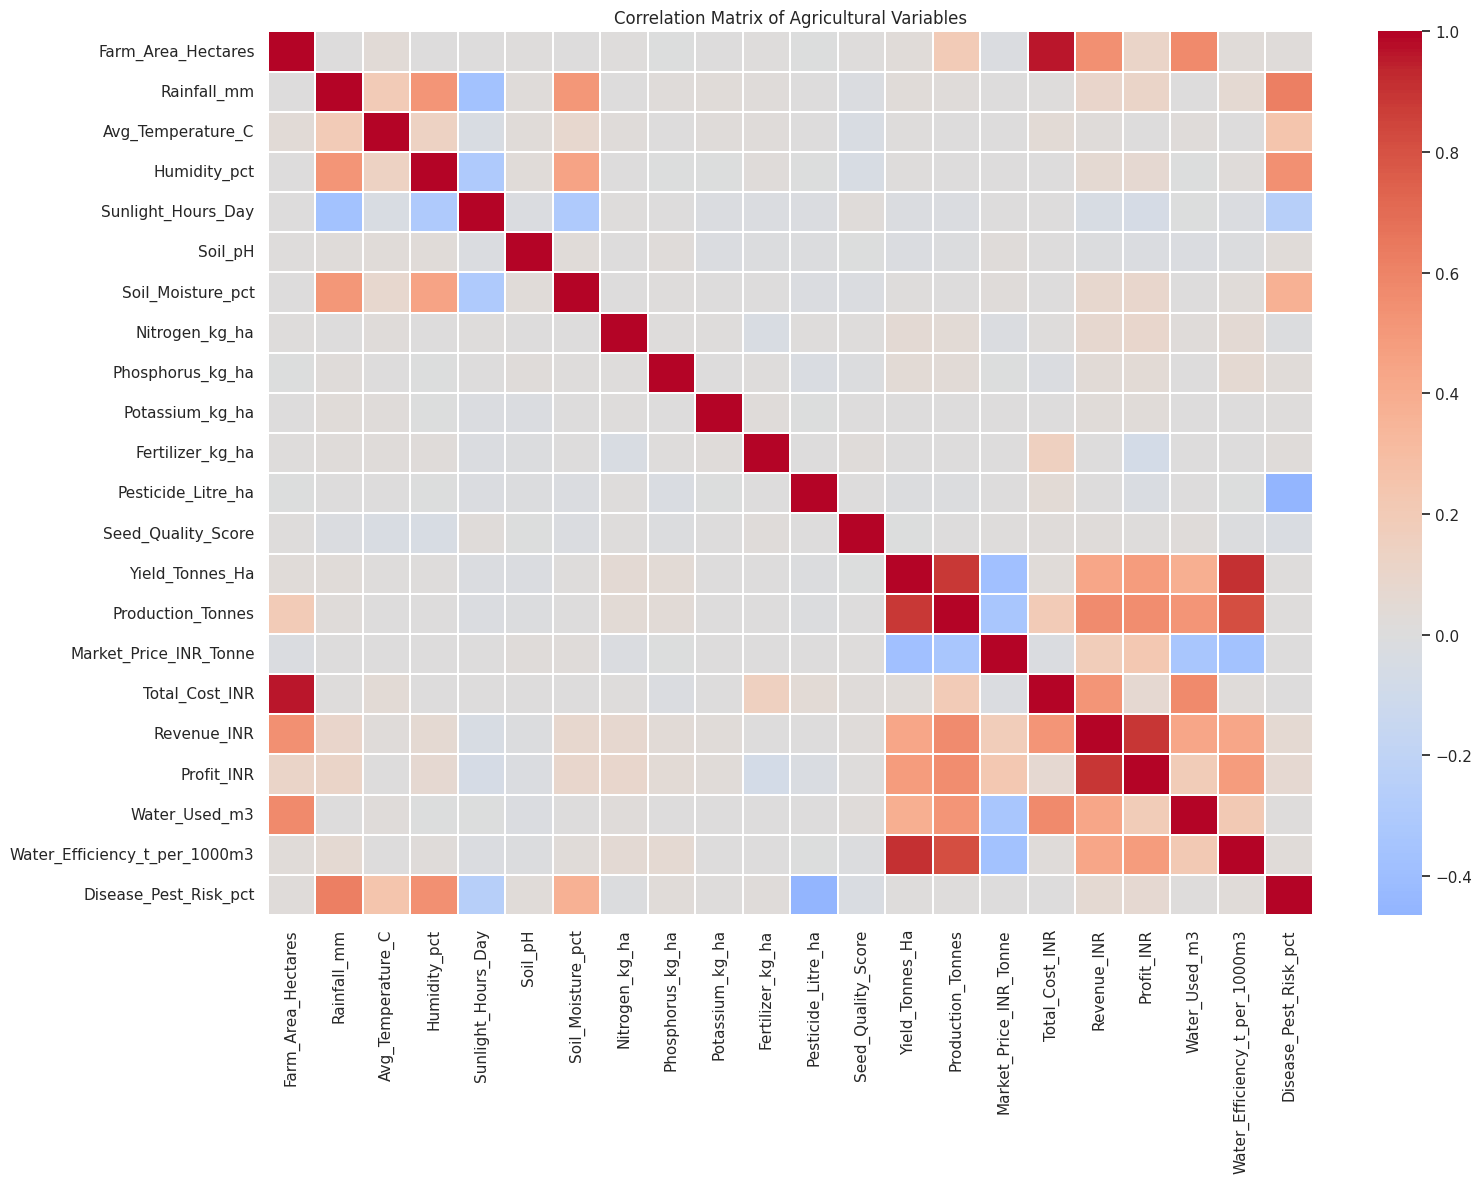

In [29]:
# Correlation Analysis

numeric_columns = clean_data.select_dtypes(
    include=np.number
).columns.tolist()

# Remove helper variable from correlation analysis
if "Profitable" in numeric_columns:
    numeric_columns.remove("Profitable")

correlation_matrix = clean_data[
    numeric_columns
].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.tight_layout()

plt.savefig(
    "outputs/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 26. Result 5 — Variables Associated with Yield

The correlation of other numerical variables with Yield_Tonnes_Ha is examined to identify the strongest positive and negative associations.

In [30]:
# Result 5: Correlation with Yield

yield_correlation = (
    correlation_matrix["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

display(
    yield_correlation.to_frame(
        "Correlation_with_Yield"
    )
)

,Correlation_with_Yield
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Total_Cost_INR,0.03


# 27. Environmental Variables and Yield

The relationship between environmental conditions and agricultural yield is examined separately to provide a focused view of environmental associations.

In [31]:
# Environmental Variables vs Yield

environmental_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Disease_Pest_Risk_pct",
    "Yield_Tonnes_Ha"
]

environment_yield_correlation = (
    clean_data[environmental_columns]
    .corr()["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

display(
    environment_yield_correlation.to_frame(
        "Correlation_with_Yield"
    )
)

,Correlation_with_Yield
Yield_Tonnes_Ha,1.00
Rainfall_mm,0.03
Disease_Pest_Risk_pct,0.01
Humidity_pct,0.01
Soil_Moisture_pct,0.01
Avg_Temperature_C,0.01
Sunlight_Hours_Day,-0.02
Soil_pH,-0.02


# 28. Statistical Testing

Statistical testing is used to investigate whether agricultural yield differs across seasons.

Both one-way ANOVA and the Kruskal-Wallis test are applied.

The Kruskal-Wallis test is particularly useful because the yield variable contains strong skewness and extreme observations.

In [32]:
# Seasonal Yield Statistical Tests

season_groups = [
    clean_data[
        clean_data["Season"] == season
    ]["Yield_Tonnes_Ha"]
    for season in ["Kharif", "Rabi", "Zaid"]
]

# One-way ANOVA
anova_statistic, anova_p_value = f_oneway(
    *season_groups
)

# Kruskal-Wallis
kruskal_statistic, kruskal_p_value = kruskal(
    *season_groups
)

print("One-way ANOVA")
print("-" * 40)
print(f"F-statistic : {anova_statistic:.4f}")
print(f"p-value     : {anova_p_value:.6f}")

print("\nKruskal-Wallis Test")
print("-" * 40)
print(f"Statistic   : {kruskal_statistic:.4f}")
print(f"p-value     : {kruskal_p_value:.12f}")

One-way ANOVA
----------------------------------------
F-statistic : 1.5439
p-value     : 0.213678

Kruskal-Wallis Test
----------------------------------------
Statistic   : 68.7131
p-value     : 0.000000000000


## Statistical Interpretation

The statistical results should be interpreted together with the distribution of the yield variable.

The ANOVA and Kruskal-Wallis tests provide complementary information. Since yield contains substantial skewness and extreme observations, the Kruskal-Wallis result provides useful non-parametric evidence regarding differences in yield distributions across seasons.

Statistical significance indicates that the observed distributions differ; it does not by itself identify the cause of those differences.

# 29. Outlier Analysis

Outlier detection is performed using the Interquartile Range (IQR) method.

This is particularly relevant for yield and production because some observations have values substantially larger than the typical observations.

In [33]:
# IQR Outlier Detection

def detect_iqr_outliers(dataframe, column):
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = dataframe[
        (dataframe[column] < lower_bound) |
        (dataframe[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound


yield_outliers, lower_bound, upper_bound = (
    detect_iqr_outliers(
        clean_data,
        "Yield_Tonnes_Ha"
    )
)

print(f"Lower IQR bound : {lower_bound:.2f}")
print(f"Upper IQR bound : {upper_bound:.2f}")
print(f"Number of yield outliers : {len(yield_outliers)}")

Lower IQR bound : -1.62
Upper IQR bound : 5.50
Number of yield outliers : 302


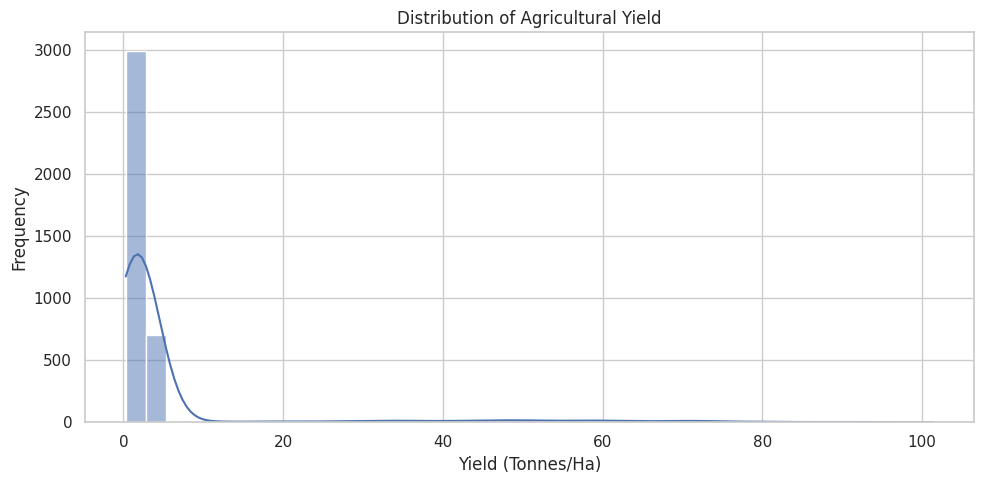

In [34]:
# Yield Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=clean_data,
    x="Yield_Tonnes_Ha",
    bins=40,
    kde=True
)

plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

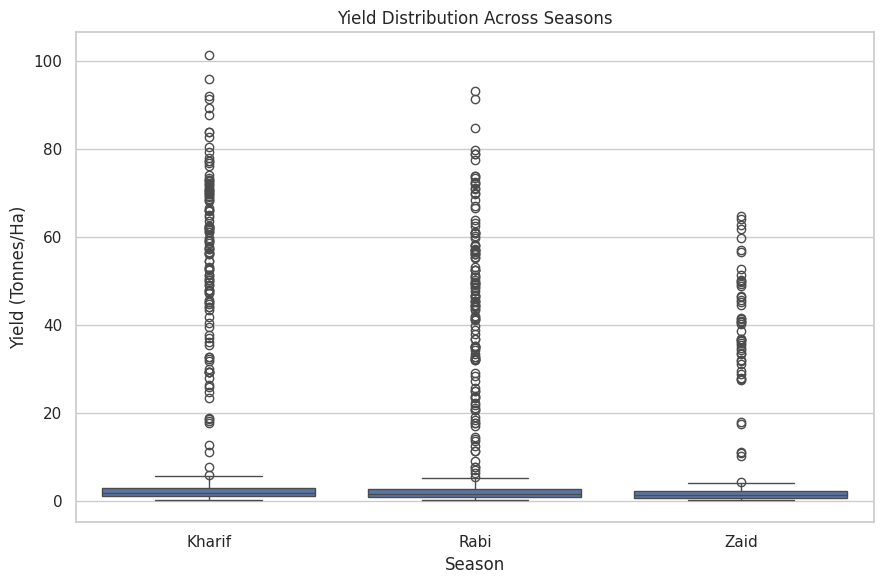

In [35]:
# Yield Distribution by Season

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=clean_data,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

# 30. Regional Analysis

Agricultural performance is compared across states to identify geographical differences in average yield, revenue, and profitability.

In [36]:
# State-wise Performance

state_summary = (
    clean_data
    .groupby("State")
    .agg(
        Farms=("Farm_ID", "count"),
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Revenue=("Revenue_INR", "mean"),
        Average_Profit=("Profit_INR", "mean")
    )
    .sort_values("Average_Yield", ascending=False)
    .round(2)
)

display(state_summary)

,Farms,Average_Yield,Average_Revenue,Average_Profit
State,,,,
Punjab,484,6.12,"686,225.70","136,025.64"
Karnataka,489,5.69,"653,426.18","119,422.34"
Gujarat,488,5.66,"654,692.86","117,568.24"
Telangana,516,5.04,"628,784.53","108,829.62"
Maharashtra,512,5.02,"650,032.67","135,428.86"
Madhya Pradesh,497,4.99,"597,558.36","86,840.76"
Tamil Nadu,485,4.88,"629,093.42","117,744.75"
Andhra Pradesh,529,4.63,"606,663.66","73,453.53"


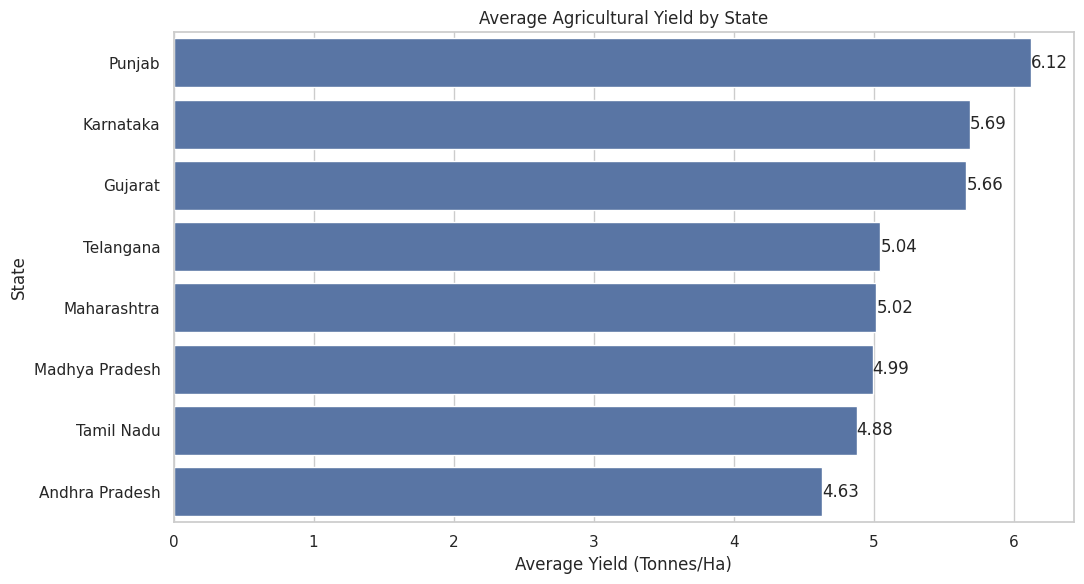

In [37]:
# State-wise Yield Visualization

state_yield = (
    clean_data
    .groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=state_yield.values,
    y=state_yield.index
)

plt.title("Average Agricultural Yield by State")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("State")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

# 31. Key Findings

The major findings from the analysis are:

1. Kharif recorded the highest average yield among the three seasons.
2. Sugarcane recorded the highest average yield among the crops.
3. Drip irrigation recorded the highest average yield among the irrigation methods.
4. Zaid recorded the highest average water usage and the lowest seasonal water efficiency.
5. Water efficiency showed a strong positive association with yield.
6. Profitability varied considerably across crops and seasons.
7. Kharif recorded the highest proportion of profitable farms.
8. The dataset contains substantial variation and extreme observations in yield.

# 32. Recommendations

Based on the observations from the dataset, the following recommendations can be considered:

1. Seasonal agricultural planning should consider differences in yield and profitability across seasons.

2. Crop selection should consider both physical yield and economic profitability.

3. Water efficiency should be monitored as an important resource-management indicator.

4. Efficient irrigation methods should be evaluated according to local conditions, crop requirements, and resource availability.

5. Disease and pest monitoring should receive greater attention during seasons with higher observed risk.

6. Regional performance should be periodically compared to identify areas requiring further investigation.

7. Environmental conditions, resource usage, crop characteristics, and economic outcomes should be considered together rather than relying on a single performance indicator.

8. Additional historical data can be incorporated in future studies to support more reliable long-term agricultural planning.

# 33. Limitations

The analysis has the following limitations:

- The findings are based only on the available dataset.
- The analysis identifies associations and does not establish causation.
- Yield contains extreme observations and substantial variation.
- The dataset represents a limited set of seasons, crops, and geographical areas.
- External agricultural factors that are not included in the dataset may also influence performance.
- Long-term trends cannot be established without additional historical observations.

Therefore, the findings should be interpreted as dataset-specific analytical observations rather than universal agricultural conclusions.

# 34. Future Scope

The project can be extended in several directions:

### Predictive Analytics
Machine learning models can be developed to predict crop yield, production, profitability, and disease/pest risk.

### Time-Series Analysis
Multi-year agricultural data can be analyzed to identify long-term seasonal and environmental trends.

### Crop Recommendation
A recommendation system could suggest suitable crops based on season, soil, environmental conditions, resource availability, and expected profitability.

### Interactive Dashboard
The analysis can be converted into an interactive dashboard using Power BI, Tableau, or Streamlit.

### Real-Time Data Integration
Weather information, market prices, soil sensors, and other real-time sources could be integrated.

### Advanced Analytics
Regression, clustering, classification, and other machine-learning techniques can be applied for deeper analysis.

# 35. Final Conclusion

The Seasonal Agriculture Performance Analysis examined agricultural performance across seasons, crops, geographical regions, irrigation methods, environmental conditions, resource usage, and economic outcomes.

The analysis identified clear differences in agricultural performance across seasons and crops. Kharif recorded the highest average yield among the three seasons, while sugarcane recorded the highest average yield among the crops represented in the dataset.

The irrigation analysis showed that drip irrigation had the highest average yield among the irrigation categories. Water-efficiency analysis highlighted differences between seasons, with Zaid showing higher average water usage but lower water efficiency.

Correlation analysis identified a strong positive association between water efficiency and yield. Economic analysis also demonstrated that agricultural performance cannot be evaluated using yield alone because profitability varies across crops and seasons.

Statistical testing and visualization provided additional evidence for understanding seasonal differences, distributions, relationships, and unusual observations.

Overall, the project demonstrates how data analytics can transform raw agricultural information into meaningful insights that can support evidence-based agricultural planning, resource management, and further investigation.

In [38]:
# 35. Final Project Summary


final_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Variables",
        "Number of Seasons",
        "Number of Crops",
        "Number of States",
        "Number of Districts",
        "Number of Irrigation Methods",
        "Missing Values After Cleaning",
        "Duplicate Records"
    ],
    "Value": [
        len(clean_data),
        clean_data.shape[1] - 1,  # Excludes helper Profitable column
        clean_data["Season"].nunique(),
        clean_data["Crop"].nunique(),
        clean_data["State"].nunique(),
        clean_data["District"].nunique(),
        clean_data["Irrigation_Method"].nunique(),
        clean_data.isnull().sum().sum(),
        clean_data.duplicated().sum()
    ]
})

display(final_summary)

,Metric,Value
0,Total Records,4000
1,Total Variables,28
2,Number of Seasons,3
3,Number of Crops,8
4,Number of States,8
5,Number of Districts,10
6,Number of Irrigation Methods,4
7,Missing Values After Cleaning,0
8,Duplicate Records,0


In [39]:
# Export Cleaned Dataset

cleaned_file = "cleaned_seasonal_agriculture_performance_dataset.csv"

clean_data.to_csv(
    cleaned_file,
    index=False
)

print(f"Cleaned dataset saved successfully as: {cleaned_file}")

Cleaned dataset saved successfully as: cleaned_seasonal_agriculture_performance_dataset.csv
